Non Preemptive SJF
PID  AT  BT  Start  CT  WT  TAT
 P1   4  10     21  31  17   27
 P2   3   2      6   8   3    5
 P3  10   8     13  21   3   11
 P4   8   5      8  13   0    5
 P5   2   4      2   6   0    4
Average Waiting Time:     4.60
Average Turnaround Time:  10.40


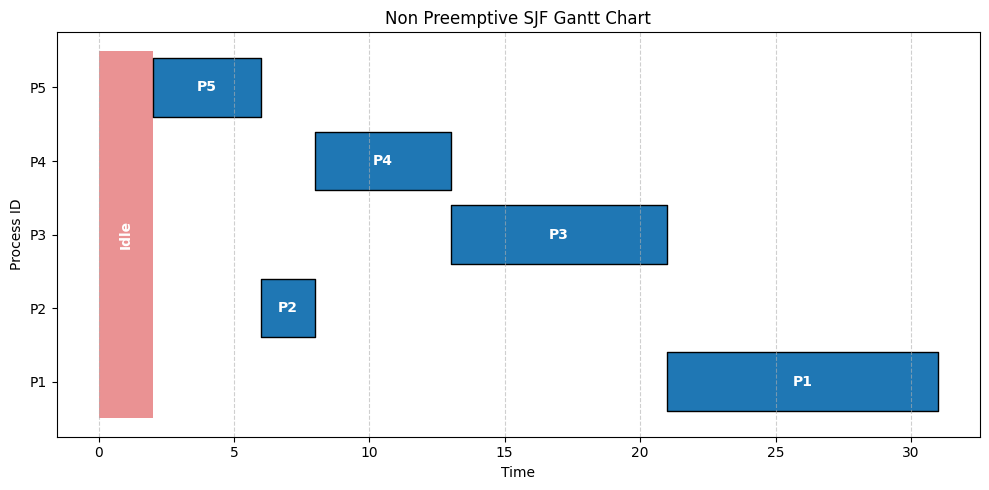

In [ ]:
import random
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Input Section ---
processes = []

n = int(input("Enter number of processes: "))
for i in range(n):
    processes.append({
        'PID': f'P{i+1}',
        'AT': random.randint(0, 10),
        'BT': random.randint(1, 10),
        'Completed': False
    })

# --- 2. Calculation Logic ---
processes.sort(key=lambda x: x['AT'])

current_time = 0
completed_count = 0
timeline = [] # (Label, Start, End)
total_tat = 0
total_wt = 0

while completed_count < n:
    # Find processes that have arrived and are not done
    available = []

    for p in processes:
        # Check if the process has arrived
        if p['AT'] <= current_time:
            # Check if the process is not yet completed
            if not p['Completed']:
                available.append(p)


    if not available:
        # If no one is here, CPU is IDLE until next arrival
        # Find the earliest arrival time among remaining processes
        remaining = []

        for p in processes:
            # Check if the process is not yet completed
            if not p['Completed']:
                remaining.append(p)

        next_arrival = min(p['AT'] for p in remaining)
        
        timeline.append(('Idle', current_time, next_arrival))
        current_time = next_arrival
    else:
        # SJF CORE LOGIC: Pick process with Minimum Burst Time
        shortest_job = min(available, key=lambda x: x['BT'])
        
        # Update Process Stats
        shortest_job['Start'] = current_time
        shortest_job['CT'] = current_time + shortest_job['BT']
        shortest_job['TAT'] = shortest_job['CT'] - shortest_job['AT']
        shortest_job['WT'] = shortest_job['TAT'] - shortest_job['BT']
        shortest_job['Completed'] = True
        
        # Update Globals
        timeline.append((shortest_job['PID'], shortest_job['Start'], shortest_job['CT']))
        total_tat += shortest_job['TAT']
        total_wt += shortest_job['WT']
        current_time = shortest_job['CT']
        completed_count += 1

avg_tat = total_tat / n
avg_wt = total_wt / n

# --- 3. Output Table ---
df = pd.DataFrame(processes).sort_values(by='PID')

print("Non Preemptive SJF")
print(df[['PID', 'AT', 'BT','Start','CT','WT','TAT']].to_string(index=False))
print(f"Average Waiting Time:    {avg_wt: .2f}")
print(f"Average Turnaround Time: {avg_tat: .2f}")

# --- 4. Plotting ---
fig, ax = plt.subplots(figsize=(10, 5))
unique_pids = df['PID'].unique()
y_pos = {pid: i for i, pid in enumerate(unique_pids)}

for label, start, end in timeline:
    duration = end - start
    if duration <= 0: continue
    
    if label == 'Idle':
        ax.broken_barh([(start, duration)], (-0.5, len(unique_pids)), facecolors='tab:red', alpha=0.5)
        ax.text(start + duration/2, len(unique_pids)/2 - 0.5, "Idle", ha='center', va='center', color='white', fontweight='bold')
    else:
        y = y_pos[label]
        ax.broken_barh([(start, duration)], (y - 0.4, 0.8), facecolors='tab:blue', edgecolor='black')
        ax.text(start + duration/2, y, label, ha='center', va='center', color='white', fontweight='bold')
    

ax.set_yticks(range(len(unique_pids)))
ax.set_yticklabels(unique_pids)
ax.set_xlabel('Time')
ax.set_ylabel('Process ID')
ax.set_title('Non Preemptive SJF Gantt Chart')
ax.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Non Preemptive SJF
PID  AT  BT  Start  CT  WT  TAT
 P1   6   5     15  20   9   14
 P2   7   4      7  11   0    4
 P3   3   2      5   7   2    4
 P4   4  10     20  30  16   26
 P5   9   4     11  15   2    6
 P6   2   3      2   5   0    3
Average Waiting Time:     4.83
Average Turnaround Time:  9.50


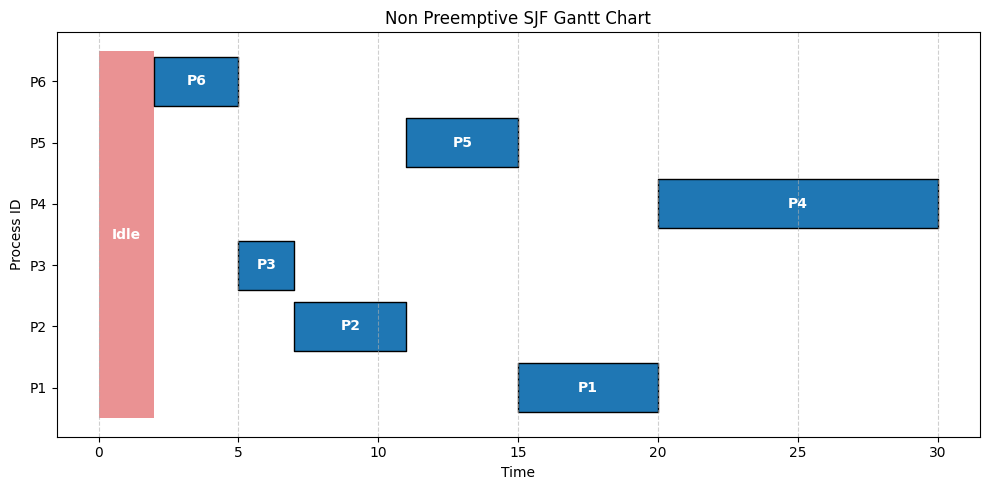

In [1]:
import random
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Input Section ---
processes = []

n = int(input("Enter number of processes: "))
for i in range(n):
    processes.append({
        'PID': f'P{i+1}',
        'AT': random.randint(0, 10),
        'BT': random.randint(1, 10),
        'Completed': False
    })

# --- 2. Calculation Logic ---
processes.sort(key=lambda x: x['AT'])

current_time = 0
completed_count = 0
timeline = [] # (Label, Start, End)
total_tat = 0
total_wt = 0

while completed_count < n:
    # Find processes that have arrived and are not done
    available = []

    for p in processes:
        # Check if the process has arrived
        if p['AT'] <= current_time:
            # Check if the process is not yet completed
            if not p['Completed']:
                available.append(p)


    if not available:
        # If no one is here, CPU is IDLE until next arrival
        # Find the earliest arrival time among remaining processes
        remaining = []

        for p in processes:
            # Check if the process is not yet completed
            if not p['Completed']:
                remaining.append(p)

        next_arrival = min(p['AT'] for p in remaining)
        
        timeline.append(('Idle', current_time, next_arrival))
        current_time = next_arrival
    else:
        # SJF CORE LOGIC: Pick process with Minimum Burst Time
        shortest_job = min(available, key=lambda x: x['BT'])
        
        # Update Process Stats
        shortest_job['Start'] = current_time
        shortest_job['CT'] = current_time + shortest_job['BT']
        shortest_job['TAT'] = shortest_job['CT'] - shortest_job['AT']
        shortest_job['WT'] = shortest_job['TAT'] - shortest_job['BT']
        shortest_job['Completed'] = True
        
        # Update Globals
        timeline.append((shortest_job['PID'], shortest_job['Start'], shortest_job['CT']))
        total_tat += shortest_job['TAT']
        total_wt += shortest_job['WT']
        current_time = shortest_job['CT']
        completed_count += 1

avg_tat = total_tat / n
avg_wt = total_wt / n

# --- 3. Output Table ---
df = pd.DataFrame(processes).sort_values(by='PID')

print("Non Preemptive SJF")
print(df[['PID', 'AT', 'BT','Start','CT','WT','TAT']].to_string(index=False))
print(f"Average Waiting Time:    {avg_wt: .2f}")
print(f"Average Turnaround Time: {avg_tat: .2f}")

# --- 4. Plotting ---
fig, ax = plt.subplots(figsize=(10, 5))
unique_pids = df['PID'].unique()
y_pos = {pid: i for i, pid in enumerate(unique_pids)}

for label, start, end in timeline:
    duration = end - start
    if duration <= 0: continue
    
    if label == 'Idle':
        ax.broken_barh([(start, duration)], (-0.5, len(unique_pids)), facecolors='tab:red', alpha=0.5)
        ax.text(start + duration/2, len(unique_pids)/2 - 0.5, "Idle", ha='center', va='center', color='white', fontweight='bold')
    else:
        y = y_pos[label]
        ax.broken_barh([(start, duration)], (y - 0.4, 0.8), facecolors='tab:blue', edgecolor='black')
        ax.text(start + duration/2, y, label, ha='center', va='center', color='white', fontweight='bold')
    

ax.set_yticks(range(len(unique_pids)))
ax.set_yticklabels(unique_pids)
ax.set_xlabel('Time')
ax.set_ylabel('Process ID')
ax.set_title('Non Preemptive SJF Gantt Chart')
ax.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()